# 02 — Economic Data Downloader
**Step 2 of Urban Expansion vs Economic Activity pipeline**

| Source | Data | Method |
|--------|------|--------|
| BEA | Metro real GDP (chained 2017$) | Bulk ZIP — no key needed |
| BLS LAUS | Employment & unemployment rate | Local files (`laucnty{yy}.xlsx`) |
| Census BPS | Building permits by CBSA | Local files (`bps_{year}.txt`) |

**Before running:**
1. Create folders: `data/raw/bls/` and `data/raw/bps/`
2. Move `laucnty13.xlsx` ... `laucnty23.xlsx` → `data/raw/bls/`
3. Move `bps_2013.txt` ... `bps_2023.txt` → `data/raw/bps/`

**Output:** `data/economic/panel.csv`

In [3]:
!pip install requests pandas openpyxl xlrd --quiet

## 1. Imports

In [5]:
import os
import io
import glob
import time
import zipfile
import requests
import pandas as pd
from io import StringIO

os.makedirs("data/economic", exist_ok=True)
os.makedirs("data/raw/bls",  exist_ok=True)
os.makedirs("data/raw/bps",  exist_ok=True)

## 2. Configuration

In [7]:
# ── Metro CBSA codes ─────────────────────────────────────────────────────────
METROS = {
    "austin":       {"cbsa": "12420"},
    "dallas":       {"cbsa": "19100"},
    "nashville":    {"cbsa": "34980"},
    "phoenix":      {"cbsa": "38060"},
    "jacksonville": {"cbsa": "27260"},
}

# ── CBSA → constituent county FIPS (state_fips, county_fips) ─────────────────
# Source: Census CBSA delineation files
CBSA_COUNTIES = {
    "austin":       [("48","021"),("48","055"),("48","209"),("48","453"),("48","491")],
    "dallas":       [("48","085"),("48","113"),("48","121"),("48","139"),("48","231"),
                     ("48","251"),("48","257"),("48","367"),("48","397"),("48","425"),
                     ("48","439"),("48","497")],
    "nashville":    [("47","003"),("47","015"),("47","021"),("47","037"),("47","043"),
                     ("47","081"),("47","111"),("47","119"),("47","147"),("47","149"),
                     ("47","159"),("47","165"),("47","169"),("47","187")],
    "phoenix":      [("04","013"),("04","021")],
    "jacksonville": [("12","003"),("12","019"),("12","031"),("12","089"),("12","109")],
}

YEARS = list(range(2013, 2024))

# Browser header for government site requests
HEADERS = {"User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) Chrome/120.0.0.0"}

print(f"Metros: {list(METROS.keys())}")
print(f"Years : {YEARS[0]}–{YEARS[-1]}")

Metros: ['austin', 'dallas', 'nashville', 'phoenix', 'jacksonville']
Years : 2013–2023


## 3. Move Downloaded Files to Raw Directories
Moves any files from the working directory into the correct `data/raw/` subfolders.

In [9]:
# Auto-move BLS files
for f in glob.glob("laucnty*.xlsx"):
    dest = f"data/raw/bls/{f}"
    os.rename(f, dest)
    print(f"Moved {f} → {dest}")

# Auto-move BPS files
for f in glob.glob("bps_*.txt") + glob.glob("bps_*.xlsx") + glob.glob("bps_*.xls"):
    dest = f"data/raw/bps/{f}"
    os.rename(f, dest)
    print(f"Moved {f} → {dest}")

# Confirm what we have
bls_files = sorted(glob.glob("data/raw/bls/laucnty*.xlsx"))
bps_files = sorted(glob.glob("data/raw/bps/bps_*.txt") +
                   glob.glob("data/raw/bps/bps_*.xlsx") +
                   glob.glob("data/raw/bps/bps_*.xls"))
print(f"\nBLS files found: {len(bls_files)}  (expect 11)")
print(f"BPS files found: {len(bps_files)}  (expect 11)")


BLS files found: 11  (expect 11)
BPS files found: 11  (expect 11)


## 4. BEA — Metro GDP (Bulk ZIP)
Downloads CAGDP9 bulk ZIP from BEA — no key needed.

In [50]:
def fetch_bea_gdp_bulk(years):
    """
    Download BEA CAGDP9 bulk ZIP, extract state CSVs, aggregate county GDP
    to metro level using CBSA_COUNTIES mapping.
    BEA discontinued metro-level GDP in 2024 — county aggregation is the
    correct approach.
    LineCode=1 = All industry total real GDP (chained 2017$, thousands).
    Converted to millions on output.
    """
    # Map metro → state file codes needed
    METRO_STATES = {
        "austin":       ["TX"],
        "dallas":       ["TX"],
        "nashville":    ["TN"],
        "phoenix":      ["AZ"],
        "jacksonville": ["FL"],
    }

    url = "https://apps.bea.gov/regional/zip/CAGDP9.zip"
    print(f"Downloading {url} ...")
    resp = requests.get(url, headers=HEADERS, timeout=120)
    resp.raise_for_status()

    # Load needed state files once
    state_dfs = {}
    with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
        available = z.namelist()
        needed_states = set(s for states in METRO_STATES.values() for s in states)
        for state in needed_states:
            fname = [f for f in available if f"CAGDP9_{state}_" in f and f.endswith(".csv")]
            if not fname:
                print(f"  [WARN] No file for state {state}")
                continue
            with z.open(fname[0]) as f:
                df = pd.read_csv(f, dtype=str, encoding="latin-1")
            # Clean GeoFIPS: strip whitespace and quotes
            df["GeoFIPS"] = (
                df["GeoFIPS"]
                .str.strip()
                .str.replace('"', '', regex=False)
                .str.strip()
            )
            # Keep only LineCode=1 (all industry total)
            df = df[df["LineCode"].str.strip() == "1"].copy()
            state_dfs[state] = df
            print(f"  Loaded {fname[0]}: {len(df)} rows")

    # Aggregate counties → metro
    all_rows = []
    year_cols = [str(y) for y in years]

    for metro, counties in CBSA_COUNTIES.items():
        states_needed = METRO_STATES[metro]
        # Build 5-digit county FIPS: state_fips(2) + county_fips(3)
        county_fips_set = {sf + cf for sf, cf in counties}

        # Gather rows for this metro's counties across relevant state dfs
        metro_rows = []
        for state in states_needed:
            if state not in state_dfs:
                continue
            df = state_dfs[state]
            matched = df[df["GeoFIPS"].isin(county_fips_set)]
            metro_rows.append(matched)

        if not metro_rows:
            print(f"  [WARN] {metro}: no county rows found")
            continue

        df_metro = pd.concat(metro_rows, ignore_index=True)
        print(f"  {metro}: {len(df_metro)} counties matched "
              f"(expect {len(counties)})")

        # Sum GDP across counties for each year
        for yr in year_cols:
            if yr not in df_metro.columns:
                continue
            vals = pd.to_numeric(
                df_metro[yr].str.replace(",", ""), errors="coerce"
            )
            total = vals.sum()
            if pd.isna(total) or total == 0:
                continue
            all_rows.append({
                "metro":        metro,
                "year":         int(yr),
                # BEA in thousands of chained 2017$ → convert to millions
                "gdp_millions": round(total / 1000, 1),
            })

    return (
        pd.DataFrame(all_rows)
        .sort_values(["metro", "year"])
        .reset_index(drop=True)
    )


gdp_df = fetch_bea_gdp_bulk(YEARS)
print(f"\nGDP rows: {len(gdp_df)}  (expect {len(CBSA_COUNTIES) * len(YEARS)})")
gdp_df

  Loaded CAGDP9_AZ_2001_2024.csv: 16 rows
  Loaded CAGDP9_TN_2001_2024.csv: 96 rows
  Loaded CAGDP9_TX_2001_2024.csv: 255 rows
  Loaded CAGDP9_FL_2001_2024.csv: 68 rows
  austin: 5 counties matched (expect 5)
  dallas: 12 counties matched (expect 12)
  nashville: 14 counties matched (expect 14)
  phoenix: 2 counties matched (expect 2)
  jacksonville: 5 counties matched (expect 5)

GDP rows: 55  (expect 55)


,metro,year,gdp_millions
0,austin,2013,113901.7
1,austin,2014,120357.5
2,austin,2015,129623.3
3,austin,2016,135022.5
4,austin,2017,141102.9
5,austin,2018,149306.1
6,austin,2019,159055.7
7,austin,2020,164257.7
8,austin,2021,182249.0
9,austin,2022,198966.5


## 5. BLS LAUS — Employment & Unemployment (Local Files)

Reads `data/raw/bls/laucnty{yy}.xlsx` — county-level BLS annual averages.  
Aggregates counties → metro level using CBSA delineation.

In [53]:
def load_bls_county_file(filepath):
    """
    Load a laucnty{yy}.xlsx file.
    Column positions (0-indexed after skiprows=4):
      [1]=state_fips, [2]=county_fips, [3]=area_name,
      [6]=employed,   [7]=unemployed,  [8]=urate
    """
    df = pd.read_excel(filepath, skiprows=4, dtype=str, header=None)
    df = df.dropna(how="all").reset_index(drop=True)
    # Drop footer rows (non-numeric state fips)
    df = df[pd.to_numeric(df[1], errors="coerce").notna()]
    df["state_fips"]  = df[1].astype(str).str.strip().str.zfill(2)
    df["county_fips"] = df[2].astype(str).str.strip().str.zfill(3)
    df["employed"]    = pd.to_numeric(df[6].astype(str).str.replace(",",""), errors="coerce")
    df["unemployed"]  = pd.to_numeric(df[7].astype(str).str.replace(",",""), errors="coerce")
    return df[["state_fips", "county_fips", "employed", "unemployed"]]


def fetch_bls_from_files(years, raw_dir="data/raw/bls"):
    """Aggregate county LAUS data to metro level for all years."""
    rows = []
    for year in years:
        yy    = str(year)[2:]
        fpath = os.path.join(raw_dir, f"laucnty{yy}.xlsx")
        if not os.path.exists(fpath):
            print(f"  [WARN] Missing: {fpath}")
            for metro in METROS:
                rows.append({"metro": metro, "year": year,
                              "unemployment_rate": None, "employment_thousands": None})
            continue

        df = load_bls_county_file(fpath)

        for metro, counties in CBSA_COUNTIES.items():
            # Filter to counties belonging to this CBSA
            mask = df.apply(
                lambda r: (r["state_fips"], r["county_fips"]) in counties, axis=1
            )
            sub = df[mask]
            if sub.empty:
                print(f"  [WARN] {year} {metro}: no county match")
                rows.append({"metro": metro, "year": year,
                              "unemployment_rate": None, "employment_thousands": None})
                continue

            emp   = sub["employed"].sum()
            unemp = sub["unemployed"].sum()
            lf    = emp + unemp
            rows.append({
                "metro":                metro,
                "year":                 year,
                "unemployment_rate":    round(unemp / lf * 100, 1) if lf > 0 else None,
                "employment_thousands": round(emp / 1000, 1),
            })

        print(f"  {year}: loaded")

    return (
        pd.DataFrame(rows)
        .sort_values(["metro", "year"])
        .reset_index(drop=True)
    )


bls_df = fetch_bls_from_files(YEARS)
print(f"\nBLS rows      : {len(bls_df)}")
print(f"Non-null urate: {bls_df['unemployment_rate'].notna().sum()}")
bls_df

  2013: loaded
  2014: loaded
  2015: loaded
  2016: loaded
  2017: loaded
  2018: loaded
  2019: loaded
  2020: loaded
  2021: loaded
  2022: loaded
  2023: loaded

BLS rows      : 55
Non-null urate: 55


,metro,year,unemployment_rate,employment_thousands
0,austin,2013,5.2,961.3
1,austin,2014,4.3,999.1
2,austin,2015,3.4,1032.2
3,austin,2016,3.3,1066.2
4,austin,2017,3.2,1104.7
5,austin,2018,3.0,1146.5
6,austin,2019,2.8,1186.9
7,austin,2020,6.3,1156.7
8,austin,2021,4.1,1255.3
9,austin,2022,3.0,1351.6


## 6. Census BPS — Building Permits (Local Files)

Reads `data/raw/bps/bps_{year}.txt` files downloaded from Census.

**File format varies by year:**
- **2013–2018**: Plain UTF-8 space-delimited text, 11 header rows. Long metro names (e.g. Nashville) wrap onto next line — handled by merging continuation lines before parsing.
- **2019–2023**: Binary OLE2 XLS disguised as `.txt`, 6 header rows. Columns: `CSA CBSA Name Total 1Unit 2Units 3-4Units 5+Units`

In [56]:
def load_bps_from_files(years, raw_dir="data/raw/bps"):
    """
    Load Census BPS CBSA files. Format varies by year:
      2013-2018 : plain UTF-8 space-delimited text, 11 header rows.
                  Long names (e.g. Nashville) wrap onto next line — merged before parsing.
                  Columns: CSA CBSA Name ... Total 1Unit 2Units 3-4Units 5+Units 5+Structures
      2019-2023 : binary OLE2 XLS (disguised as .txt), 6 header rows.
                  Columns: CSA CBSA Name Total 1Unit 2Units 3-4Units 5+Units ...
    """
    cbsa_to_metro = {cfg["cbsa"]: metro for metro, cfg in METROS.items()}
    all_rows = []

    def safe_int(v):
        try: return int(str(v).replace(",", "").strip())
        except: return 0

    def get_file_type(fpath):
        with open(fpath, "rb") as f:
            magic = f.read(4)
        if magic[:2] == b'\xd0\xcf':
            return "xls_binary"
        if magic[:4] == b'PK\x03\x04':
            return "xlsx"
        return "txt"

    for year in years:
        fpath = None
        for ext in ["txt", "TXT", "xlsx", "xls"]:
            c = os.path.join(raw_dir, f"bps_{year}.{ext}")
            if os.path.exists(c):
                fpath = c
                break

        if fpath is None:
            print(f"  [WARN] {year}: file not found")
            for metro in METROS:
                all_rows.append({"metro": metro, "year": year, "total_permits": None})
            continue

        try:
            ftype = get_file_type(fpath)

            if ftype in ("xls_binary", "xlsx"):
                # 2019-2023: binary XLS/XLSX, skiprows=6
                # Row 5 (0-indexed) = header: CSA CBSA Name Total 1Unit 2Units 3-4Units 5+Units
                engine = "xlrd" if ftype == "xls_binary" else "openpyxl"
                df = pd.read_excel(fpath, dtype=str, header=None,
                                   skiprows=6, engine=engine)
                # col 0=CSA, 1=CBSA, 2=Name, 3=Total, 4=1unit, 5=2units, 6=3-4units, 7=5+units
                df[1] = df[1].astype(str).str.strip().str.zfill(5)
                df_filt = df[df[1].isin(cbsa_to_metro)]

                assert len(df_filt) == len(METROS), \
                    f"expected {len(METROS)} rows, got {len(df_filt)}"

                for _, row in df_filt.iterrows():
                    total = safe_int(row[4]) + safe_int(row[5]) + safe_int(row[6]) + safe_int(row[7])
                    all_rows.append({
                        "metro":         cbsa_to_metro[row[1]],
                        "year":          year,
                        "total_permits": total,
                    })

            else:
                # 2013-2018: plain space-delimited text, 11 header rows
                # Nashville-Davidson--Murfreesboro--Franklin line wraps onto next line
                # — merge continuation lines before parsing
                with open(fpath, encoding="utf-8") as f:
                    lines = f.readlines()

                # First pass: merge wrapped lines back onto their parent line
                merged = []
                for i, line in enumerate(lines):
                    if i < 11:
                        continue
                    stripped = line.rstrip("\n")
                    if not stripped.strip():
                        continue
                    tokens = stripped.split()
                    if not tokens:
                        continue
                    # Real data line: starts with two numeric tokens (CSA, CBSA)
                    if tokens[0].isdigit() and len(tokens) > 1 and tokens[1].isdigit():
                        merged.append(stripped)
                    else:
                        # Continuation of previous wrapped line
                        if merged:
                            merged[-1] = merged[-1] + " " + stripped.strip()

                # Second pass: parse merged lines and filter to our metros
                matched = []
                for line in merged:
                    tokens = line.split()
                    if len(tokens) < 8:
                        continue
                    cbsa = tokens[1].zfill(5)
                    if cbsa not in cbsa_to_metro:
                        continue
                    # Last 6 tokens: Total 1Unit 2Units 3-4Units 5+Units 5+Structures
                    nums = tokens[-6:]
                    total = safe_int(nums[1]) + safe_int(nums[2]) + safe_int(nums[3]) + safe_int(nums[4])
                    matched.append({
                        "metro":         cbsa_to_metro[cbsa],
                        "year":          year,
                        "total_permits": total,
                    })

                assert len(matched) == len(METROS), \
                    f"expected {len(METROS)} rows, got {len(matched)}"
                all_rows.extend(matched)

            print(f"  {year}: {len(METROS)} metros matched v")

        except AssertionError as e:
            print(f"  [WARN] {year}: {e}")
            for metro in METROS:
                all_rows.append({"metro": metro, "year": year, "total_permits": None})
        except Exception as e:
            print(f"  {year}: FAILED - {e}")
            for metro in METROS:
                all_rows.append({"metro": metro, "year": year, "total_permits": None})

    return (
        pd.DataFrame(all_rows)
        .sort_values(["metro", "year"])
        .reset_index(drop=True)
    )


# Verify files are present
bps_found = sorted(glob.glob("data/raw/bps/bps_*.txt") +
                   glob.glob("data/raw/bps/bps_*.xlsx"))
print(f"BPS files found: {len(bps_found)}  (expect 11)\n")

permits_df = load_bps_from_files(YEARS)
print(f"\nPermits rows: {len(permits_df)}")
permits_df

BPS files found: 11  (expect 11)

  2013: 5 metros matched v
  2014: 5 metros matched v
  2015: 5 metros matched v
  2016: 5 metros matched v
  2017: 5 metros matched v
  2018: 5 metros matched v
  2019: 5 metros matched v
  2020: 5 metros matched v
  2021: 5 metros matched v
  2022: 5 metros matched v
  2023: 5 metros matched v

Permits rows: 55


,metro,year,total_permits
0,austin,2013,20852
1,austin,2014,20276
2,austin,2015,22370
3,austin,2016,21861
4,austin,2017,26700
5,austin,2018,30035
6,austin,2019,32037
7,austin,2020,42264
8,austin,2021,50907
9,austin,2022,42362


## 7. Merge into Panel

In [59]:
panel = (
    gdp_df
    .merge(bls_df,     on=["metro", "year"], how="outer")
    .merge(permits_df, on=["metro", "year"], how="outer")
    .sort_values(["metro", "year"])
    .reset_index(drop=True)
)

panel = panel[[
    "metro", "year",
    "gdp_millions",          # BEA: real GDP chained 2017 $M
    "employment_thousands",  # BLS: employed (thousands)
    "unemployment_rate",     # BLS: unemployment rate (%)
    "total_permits",         # Census: total residential permits
]]

print(f"Panel shape: {panel.shape}")
print(f"\nMissing values:\n{panel.isnull().sum()}")
panel

Panel shape: (55, 6)

Missing values:
metro                   0
year                    0
gdp_millions            0
employment_thousands    0
unemployment_rate       0
total_permits           0
dtype: int64


,metro,year,gdp_millions,employment_thousands,unemployment_rate,total_permits
0,austin,2013,113901.7,961.3,5.2,20852
1,austin,2014,120357.5,999.1,4.3,20276
2,austin,2015,129623.3,1032.2,3.4,22370
3,austin,2016,135022.5,1066.2,3.3,21861
4,austin,2017,141102.9,1104.7,3.2,26700
5,austin,2018,149306.1,1146.5,3.0,30035
6,austin,2019,159055.7,1186.9,2.8,32037
7,austin,2020,164257.7,1156.7,6.3,42264
8,austin,2021,182249.0,1255.3,4.1,50907
9,austin,2022,198966.5,1351.6,3.0,42362


## 8. Handle Missing Values

In [61]:
panel_filled = (
    panel
    .groupby("metro", group_keys=False)
    .apply(lambda g: g.set_index("year").interpolate(method="index").reset_index())
    .reset_index(drop=True)
)
panel_filled["interpolated"] = panel.isnull().any(axis=1).values

print(f"Interpolated rows: {panel_filled['interpolated'].sum()}")
print(f"Remaining NaNs   : {panel_filled.isnull().sum().sum()}")
panel_filled.head(15)

Interpolated rows: 0
Remaining NaNs   : 0


/var/folders/jj/vqf744cs7fv8c4flnhd6plph0000gn/T/ipykernel_97525/2579077109.py:4: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  .apply(lambda g: g.set_index("year").interpolate(method="index").reset_index())
/var/folders/jj/vqf744cs7fv8c4flnhd6plph0000gn/T/ipykernel_97525/2579077109.py:4: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  .apply(lambda g: g.set_index("year").interpolate(method="index").reset_index())
/var/folders/jj/vqf744cs7fv8c4flnhd6plph0000gn/T/ipykernel_97525/2579077109.py:4: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  .apply(lambda g: g.set_index("year").interpolate(method="index").reset_index()

,year,metro,gdp_millions,employment_thousands,unemployment_rate,total_permits,interpolated
0,2013,austin,113901.7,961.3,5.2,20852,False
1,2014,austin,120357.5,999.1,4.3,20276,False
2,2015,austin,129623.3,1032.2,3.4,22370,False
3,2016,austin,135022.5,1066.2,3.3,21861,False
4,2017,austin,141102.9,1104.7,3.2,26700,False
5,2018,austin,149306.1,1146.5,3.0,30035,False
6,2019,austin,159055.7,1186.9,2.8,32037,False
7,2020,austin,164257.7,1156.7,6.3,42264,False
8,2021,austin,182249.0,1255.3,4.1,50907,False
9,2022,austin,198966.5,1351.6,3.0,42362,False


## 9. Save Panel

In [64]:
out_path = "data/economic/panel.csv"
panel_filled.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"Shape  : {panel_filled.shape}")
print(f"Metros : {panel_filled['metro'].unique().tolist()}")
print(f"Years  : {sorted(panel_filled['year'].unique().tolist())}")

Saved: data/economic/panel.csv
Shape  : (55, 7)
Metros : ['austin', 'dallas', 'jacksonville', 'nashville', 'phoenix']
Years  : [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


## 10. EDA — Panel Overview

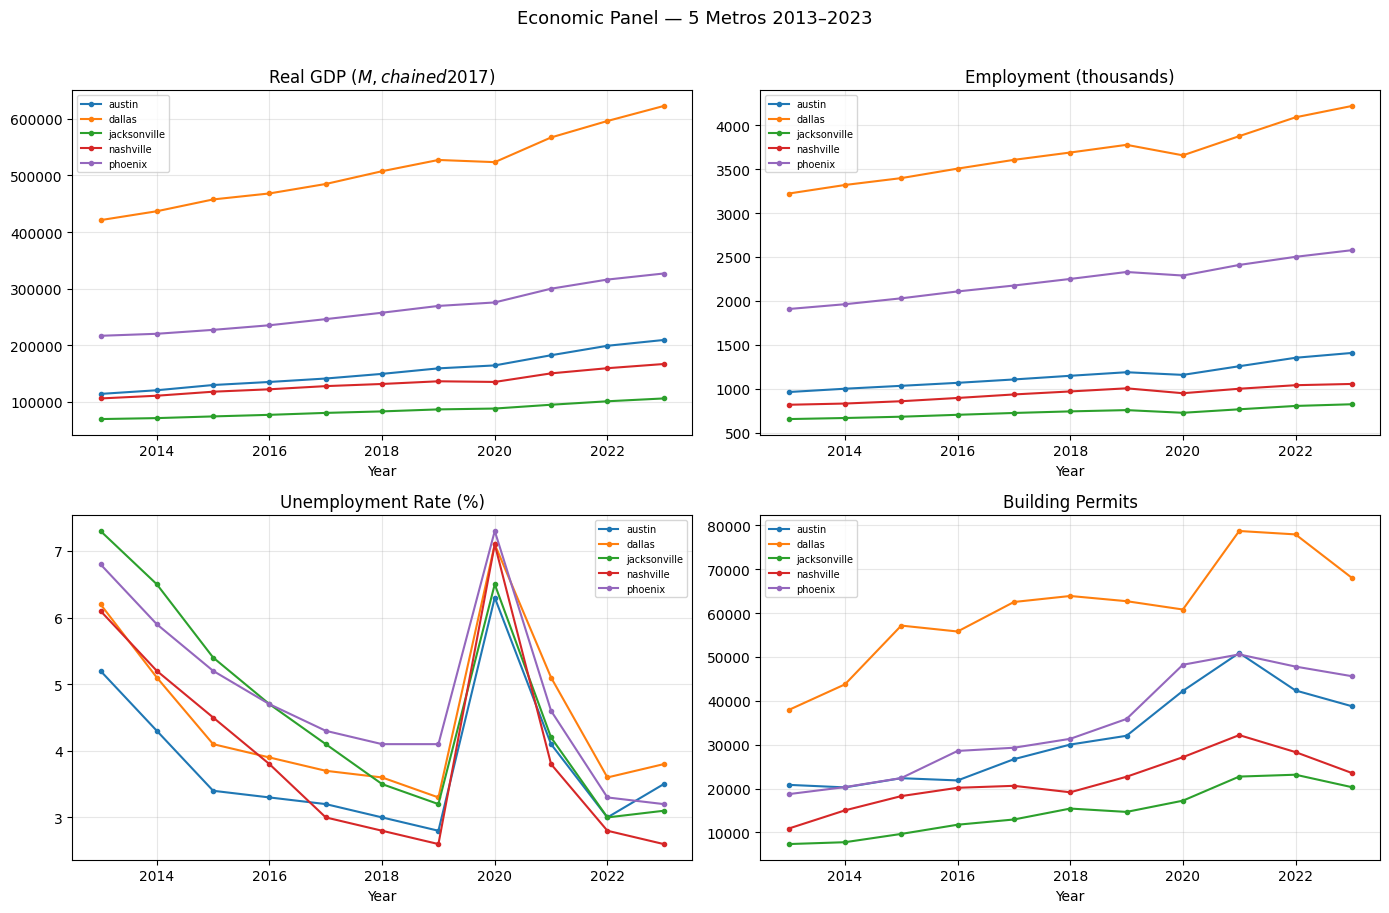

In [67]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
metrics = [
    ("gdp_millions",         "Real GDP ($M, chained 2017$)"),
    ("employment_thousands", "Employment (thousands)"),
    ("unemployment_rate",    "Unemployment Rate (%)"),
    ("total_permits",        "Building Permits"),
]
for ax, (col, label) in zip(axes.flat, metrics):
    for metro, grp in panel_filled.groupby("metro"):
        ax.plot(grp["year"], grp[col], marker="o", markersize=3, label=metro)
    ax.set_title(label)
    ax.set_xlabel("Year")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("Economic Panel — 5 Metros 2013–2023", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Output
```
data/economic/
└── panel.csv   ← metro, year, gdp_millions, employment_thousands,
                    unemployment_rate, total_permits, interpolated
```
**Next step → `03_raster_preprocessing.ipynb`**